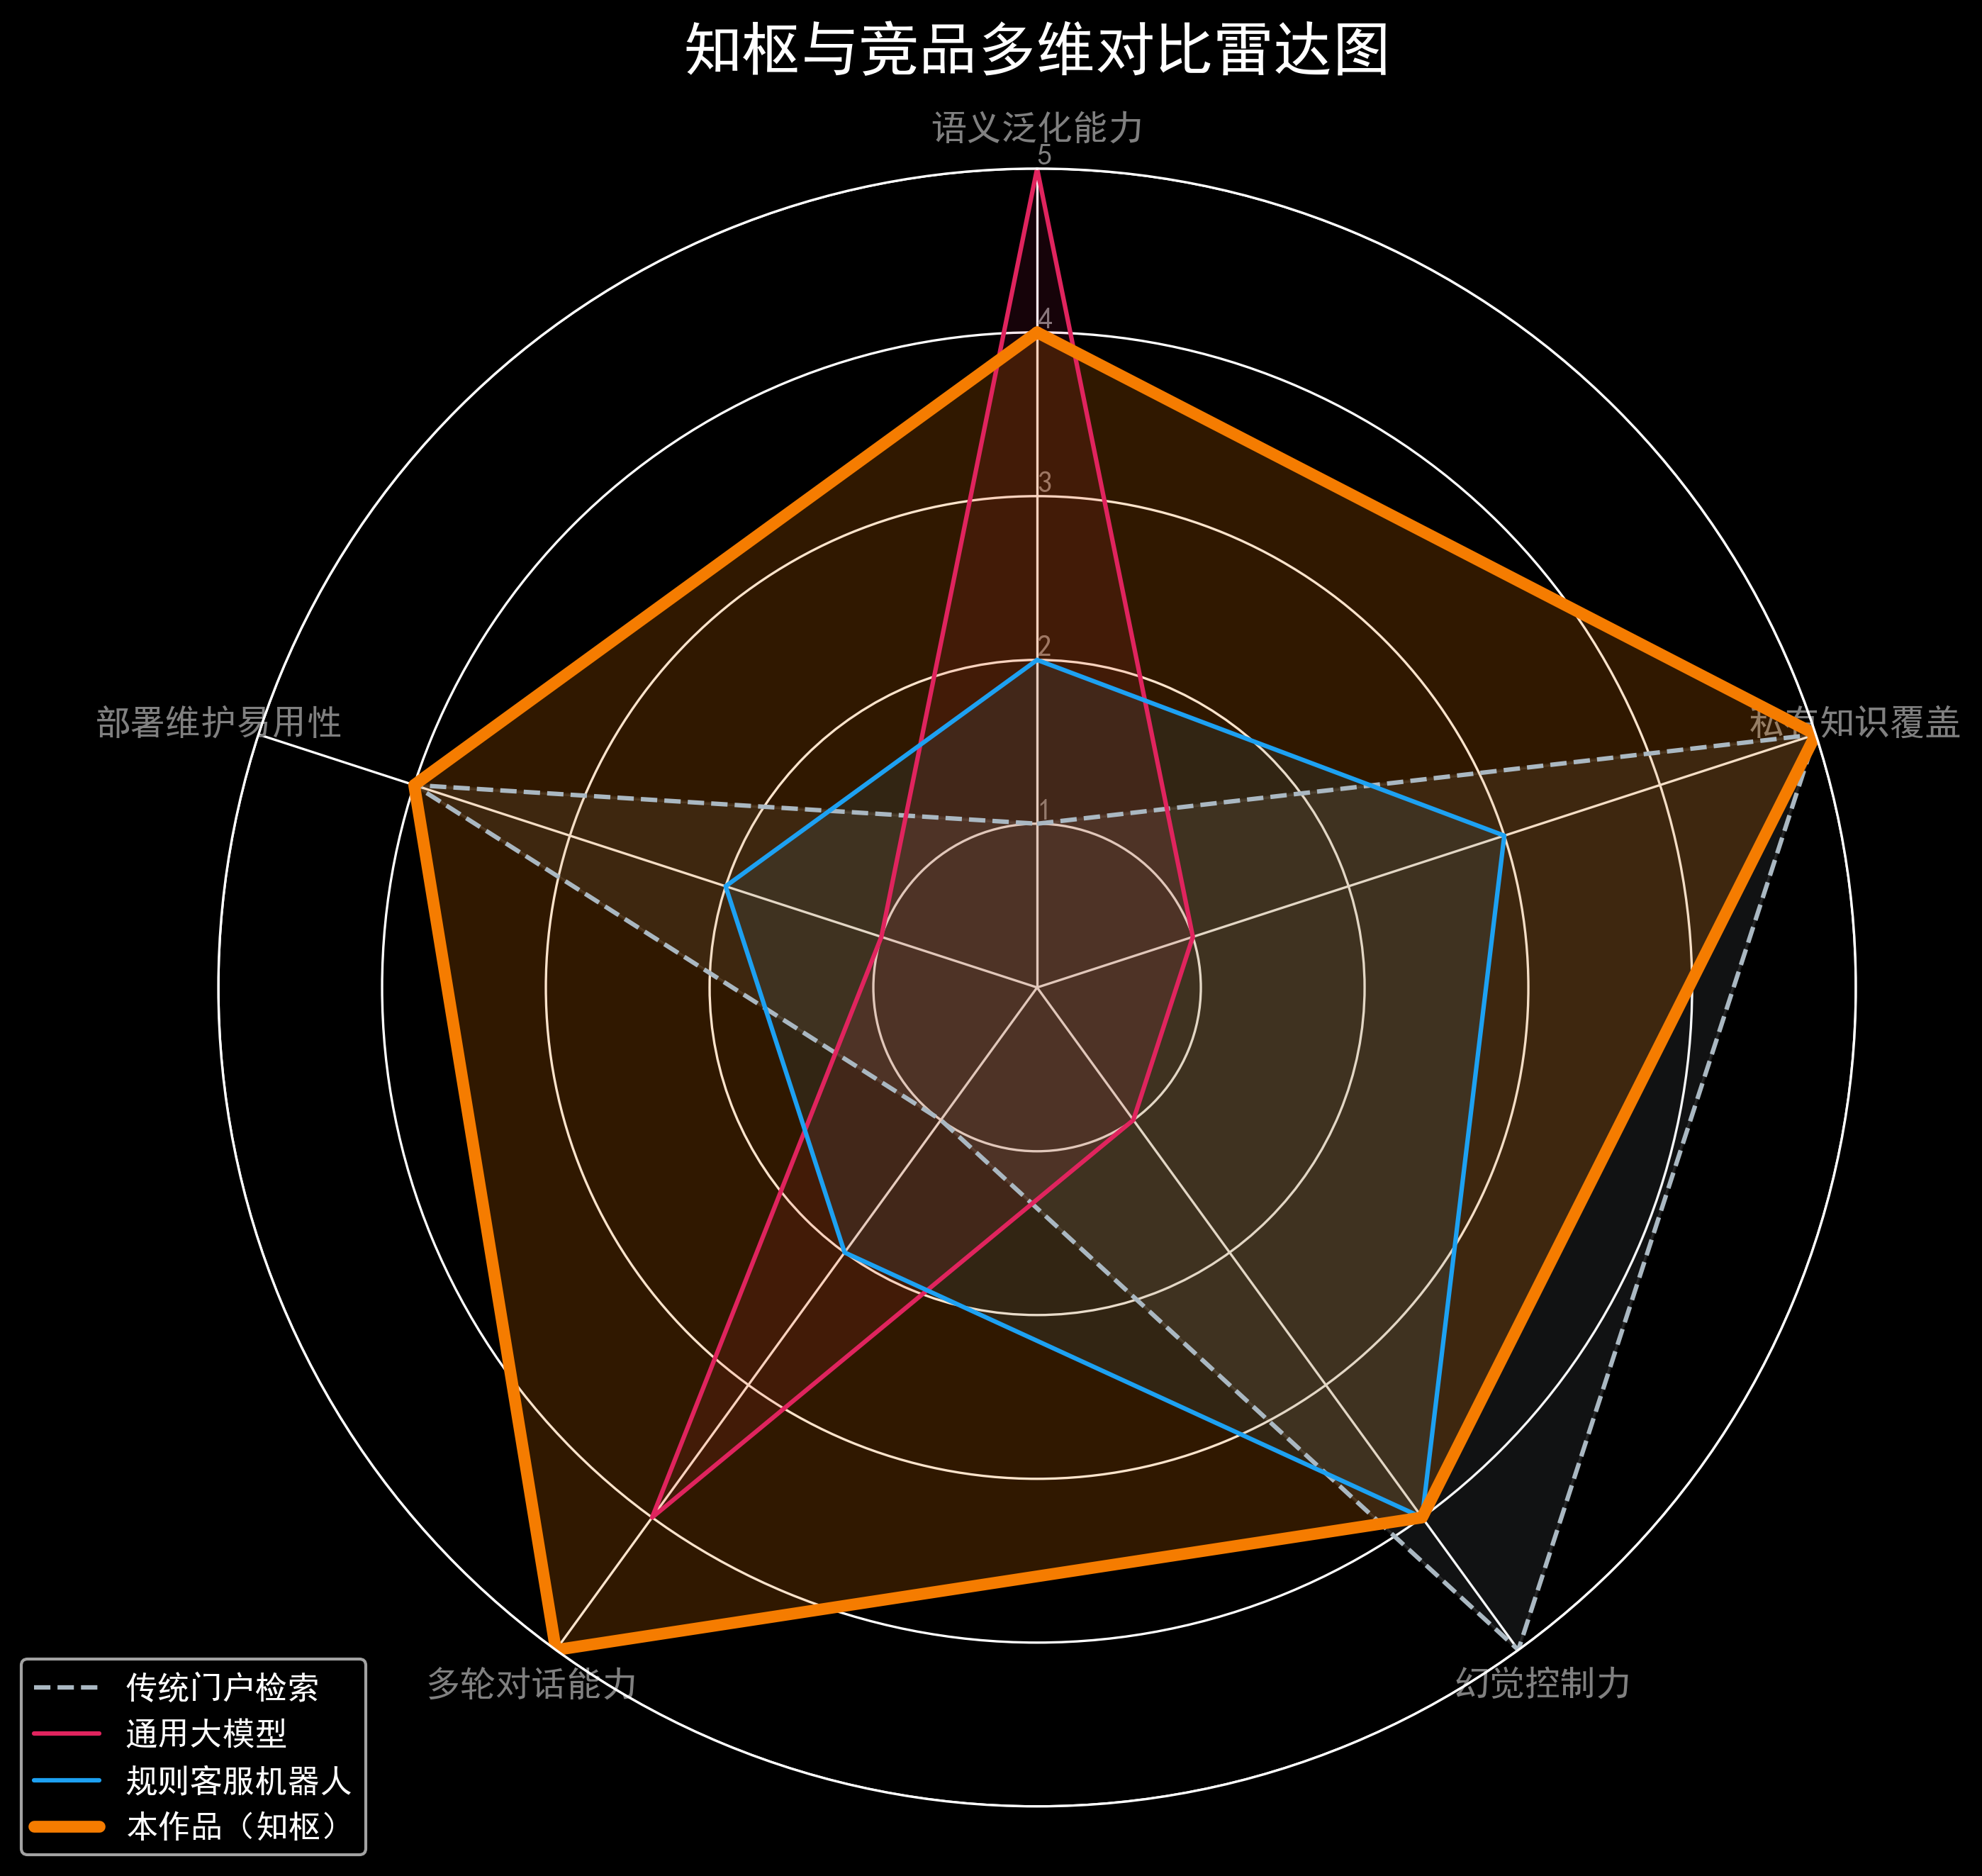

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from math import pi

# 1. 解决中文显示问题 (根据系统调整字体，Windows通常是SimHei, Mac是Arial Unicode MS)
plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号

# 2. 设定数据
df = pd.DataFrame({
    'group': ['传统门户检索', '通用大模型', '规则客服机器人', '本作品（知枢）'],
    '语义泛化能力': [1, 5, 2, 4],
    '私有知识覆盖': [5, 1, 3, 5],
    '幻觉控制力': [5, 1, 4, 4],
    '多轮对话能力': [1, 4, 2, 5],
    '部署维护易用性': [4, 1, 2, 4]
})

# 3. 目标维度的数量
categories = list(df)[1:]
N = len(categories)

# 4. 计算角度
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # 闭合图形

# 5. 初始化绘图
fig = plt.figure(figsize=(10, 10), dpi=300) # 设置高DPI，国奖水平清晰度
ax = plt.subplot(111, polar=True)

# 6. 设置坐标轴标签方向
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# 7. 添加雷达图的网格
plt.xticks(angles[:-1], categories, color='grey', size=12)

# 8. 设置Y轴（刻度）
ax.set_rlabel_position(0)
plt.yticks([1, 2, 3, 4, 5], ["1", "2", "3", "4", "5"], color="grey", size=10)
plt.ylim(0, 5)

# 9. 绘制各个竞品的数据线

# 竞品1: 传统门户 (灰色，虚线)
values = df.loc[0].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1.5, linestyle='--', label="传统门户检索", color='#AAB8C2')
ax.fill(angles, values, '#AAB8C2', alpha=0.1)

# 竞品2: 通用大模型 (红色)
values = df.loc[1].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1.5, linestyle='-', label="通用大模型", color='#E0245E')
ax.fill(angles, values, '#E0245E', alpha=0.1)

# 竞品3: 规则机器人 (蓝色)
values = df.loc[2].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1.5, linestyle='-', label="规则客服机器人", color='#1DA1F2')
ax.fill(angles, values, '#1DA1F2', alpha=0.1)

# 本作品: 知枢 (橙色，加粗)
values = df.loc[3].drop('group').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=4, linestyle='-', label="本作品（知枢）", color='#F57C00') # 突出显示
ax.fill(angles, values, '#F57C00', alpha=0.2) # 填充颜色

# 10. 添加图例
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=11)

# 11. 标题
plt.title("知枢与竞品多维对比雷达图", size=20, y=1.05)

# 保存图片
plt.savefig('competitor_analysis_radar.png', bbox_inches='tight')

plt.show()